# 03 Univariate EDA

This notebook is the first exploratory analysis notebook for the OW Yellow Caps BI project. It focuses only on univariate EDA: one variable at a time, with executive-oriented summaries, clear charts, and short business implications.

The notebook uses the completed analytical dataset from `Data/processed/analytical/analytical.parquet`. It does not modify preprocessing or feature engineering work.

## TOR Focus

Section 5.2 requires executive-ready KPIs, major insights, supporting charts, business implications, and clear caveats. Section 6.1 requires univariate coverage of trip volume over time; distributions of trip distance, trip duration, fare amount, total amount, and passenger count; plus payment type and rate code frequencies.

In [1]:
from pathlib import Path
import os
import tempfile

MPLCONFIG_DIR = Path(tempfile.gettempdir()) / "data_vis_project_matplotlib"
MPLCONFIG_DIR.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

import numpy as np
import pandas as pd
import matplotlib

if "get_ipython" not in globals():
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titleweight": "bold",
})

PRIMARY = "#1f77b4"
SECONDARY = "#4c78a8"
ACCENT = "#f58518"
NEUTRAL = "#6b7280"

## Load Analytical Dataset and Review Columns

The analytical layer is loaded from the processed output folder. Only fields needed for univariate EDA are loaded to keep the notebook responsive on a large dataset.

In [2]:
PROJECT_ROOT = Path.cwd()
ANALYTICAL_PATH = PROJECT_ROOT / "Data" / "processed" / "analytical" / "analytical.parquet"

if not ANALYTICAL_PATH.exists():
    raise FileNotFoundError(f"Analytical dataset not found: {ANALYTICAL_PATH}")

EDA_COLUMNS = [
    "pickup_date", "pickup_month", "pickup_day", "pickup_hour", "is_weekend",
    "trip_distance", "trip_duration_min", "fare_amount", "total_amount",
    "tip_percent", "passenger_count", "payment_type", "RatecodeID",
    "invalid_trip_duration", "invalid_tip_percent", "invalid_avg_speed",
]

eda = pd.read_parquet(ANALYTICAL_PATH, columns=EDA_COLUMNS)
eda["pickup_date"] = pd.to_datetime(eda["pickup_date"], errors="coerce")
eda["pickup_month"] = eda["pickup_month"].astype("string")

print(f"Loaded: {ANALYTICAL_PATH}")
print(f"Rows: {eda.shape[0]:,} | Columns loaded: {eda.shape[1]:,}")
eda.head()

Loaded: c:\Users\abd\Desktop\Data-Vis-Project\Data\processed\analytical\analytical.parquet
Rows: 11,198,026 | Columns loaded: 16


,pickup_date,pickup_month,pickup_day,pickup_hour,is_weekend,trip_distance,trip_duration_min,fare_amount,total_amount,tip_percent,passenger_count,payment_type,RatecodeID,invalid_trip_duration,invalid_tip_percent,invalid_avg_speed
0,2025-01-01,2025-01,Wednesday,0,False,1.60,8.35,10.00,18.00,30.00,1.00,1,1.00,False,False,False
1,2025-01-01,2025-01,Wednesday,0,False,0.50,2.55,5.10,12.12,39.61,1.00,1,1.00,False,False,False
2,2025-01-01,2025-01,Wednesday,0,False,0.60,1.95,5.10,12.10,39.22,1.00,1,1.00,False,False,False
3,2025-01-01,2025-01,Wednesday,0,False,0.52,5.57,7.20,9.70,0.00,3.00,2,1.00,False,False,False
4,2025-01-01,2025-01,Wednesday,0,False,0.66,3.53,5.80,8.30,0.00,3.00,2,1.00,False,False,False


In [3]:
column_review = pd.DataFrame({
    "column": eda.columns,
    "dtype": [str(dtype) for dtype in eda.dtypes],
    "missing_rows": [int(eda[column].isna().sum()) for column in eda.columns],
    "missing_pct": [eda[column].isna().mean() * 100 for column in eda.columns],
})
column_review

,column,dtype,missing_rows,missing_pct
0,pickup_date,datetime64[ns],0,0.00
1,pickup_month,string,0,0.00
2,pickup_day,object,0,0.00
3,pickup_hour,Int64,0,0.00
4,is_weekend,boolean,0,0.00
5,trip_distance,float64,0,0.00
6,trip_duration_min,float64,29542,0.26
7,fare_amount,float64,0,0.00
8,total_amount,float64,0,0.00
9,tip_percent,float64,552831,4.94


In [4]:
Q1_START = pd.Timestamp("2025-01-01")
Q1_END = pd.Timestamp("2025-03-31")
q1_mask = eda["pickup_date"].between(Q1_START, Q1_END)
q1 = eda.loc[q1_mask].copy()
out_of_period_rows = int((~q1_mask).sum())

print(f"Rows inside Q1 2025: {len(q1):,}")
print(f"Rows outside Q1 2025 retained in analytical file but excluded from time-trend charts: {out_of_period_rows:,}")

Rows inside Q1 2025: 11,198,001
Rows outside Q1 2025 retained in analytical file but excluded from time-trend charts: 25


**Observation:** The analytical file is large and contains the engineered fields required for EDA. A very small number of records fall outside the Q1 2025 reporting window.

**Interpretation:** Out-of-window dates are data-quality caveats, not operating trends.

**Business implication:** Time-trend visuals use Q1 2025 records only, while the notebook still reports the presence of suspicious date records for transparency.

## Helper Functions

The helpers below standardize tables and charts across the notebook. Histograms and boxplots use clipping at high percentiles where needed so extreme records do not hide the main operating pattern.

In [5]:
def format_count(value):
    return f"{value:,.0f}"


def format_money(value):
    return f"${value:,.2f}"


def format_number(value):
    return f"{value:,.2f}"


def summary_stats(df, column):
    s = pd.to_numeric(df[column], errors="coerce")
    return pd.DataFrame({
        "metric": ["count", "missing", "mean", "median", "std", "min", "p05", "p25", "p75", "p95", "p99", "max", "negative_rows", "zero_rows"],
        "value": [
            s.count(), s.isna().sum(), s.mean(), s.median(), s.std(), s.min(),
            s.quantile(0.05), s.quantile(0.25), s.quantile(0.75),
            s.quantile(0.95), s.quantile(0.99), s.max(),
            (s < 0).sum(), (s == 0).sum(),
        ],
    })


def clipped_series(df, column, lower_q=0.00, upper_q=0.99):
    s = pd.to_numeric(df[column], errors="coerce").dropna()
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s[(s >= lower) & (s <= upper)], lower, upper


def plot_histogram(df, column, title, xlabel, lower_q=0.00, upper_q=0.99, bins=50, color=PRIMARY):
    s, lower, upper = clipped_series(df, column, lower_q, upper_q)
    fig, ax = plt.subplots(figsize=(11, 5.5))
    sns.histplot(s, bins=bins, kde=False, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Trip records")
    ax.text(
        0.99, 0.95,
        f"Displayed range: {lower:,.2f} to {upper:,.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        color=NEUTRAL,
    )
    plt.tight_layout()
    plt.show()


def plot_boxplot(df, column, title, xlabel, lower_q=0.00, upper_q=0.99, color=ACCENT):
    s, lower, upper = clipped_series(df, column, lower_q, upper_q)
    fig, ax = plt.subplots(figsize=(11, 2.8))
    sns.boxplot(x=s, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.text(
        0.99, 0.85,
        f"Displayed range: {lower:,.2f} to {upper:,.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        color=NEUTRAL,
    )
    plt.tight_layout()
    plt.show()


def plot_frequency_table(counts, title, xlabel, ylabel, color=PRIMARY):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    sns.barplot(x=counts.index.astype(str), y=counts.values, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v:,.0f}" for v in counts.values], fontsize=9, padding=3)
    plt.tight_layout()
    plt.show()

# 1. Executive KPI Summary

This section summarizes the operating scale and headline economics of the analytical dataset.

In [6]:
kpis = pd.DataFrame({
    "KPI": [
        "Total trips",
        "Total revenue",
        "Average trip distance",
        "Average trip duration",
        "Average fare amount",
        "Average total amount",
        "Average tip percentage",
    ],
    "Value": [
        format_count(len(eda)),
        format_money(eda["total_amount"].sum()),
        f"{eda['trip_distance'].mean():,.2f} miles",
        f"{eda['trip_duration_min'].mean():,.2f} minutes",
        format_money(eda["fare_amount"].mean()),
        format_money(eda["total_amount"].mean()),
        f"{eda['tip_percent'].mean():,.2f}%",
    ],
})
kpis

,KPI,Value
0,Total trips,"11,198,026"
1,Total revenue,"$287,431,793.68"
2,Average trip distance,6.18 miles
3,Average trip duration,15.54 minutes
4,Average fare amount,$17.24
5,Average total amount,$25.67
6,Average tip percentage,18.35%


**Observation:** The analytical file contains about 11.2 million trips and roughly $287.4 million in recorded total amount. Mean trip distance is materially higher than the median because a small number of extreme distance records remain visible in the analytical layer.

**Interpretation:** The KPI table is useful for scale, but averages should be read alongside medians and percentile checks because taxi trip data is right-skewed.

**Business implication:** Executive reporting should use both totals and robust measures such as medians or percentile-bounded views when discussing typical trip behavior.

# 2. Trip Volume Over Time

Trip volume is reviewed daily, weekly, and monthly. Time charts are restricted to January 1 through March 31, 2025 so date anomalies do not distort the trend.

In [7]:
daily_trips = q1.groupby("pickup_date").size().rename("trip_count")
weekly_trips = daily_trips.resample("W-MON").sum()
monthly_trips = q1.groupby("pickup_month").size().rename("trip_count")
rolling_7d = daily_trips.rolling(window=7, min_periods=3).mean()

trend_summary = pd.DataFrame({
    "metric": ["daily_mean", "daily_median", "daily_min", "daily_max", "peak_day", "lowest_day"],
    "value": [
        daily_trips.mean(), daily_trips.median(), daily_trips.min(), daily_trips.max(),
        daily_trips.idxmax().date(), daily_trips.idxmin().date(),
    ],
})
trend_summary

,metric,value
0,daily_mean,"124,422.23"
1,daily_median,"125,208.50"
2,daily_min,79624
3,daily_max,164226
4,peak_day,2025-03-01
5,lowest_day,2025-01-05


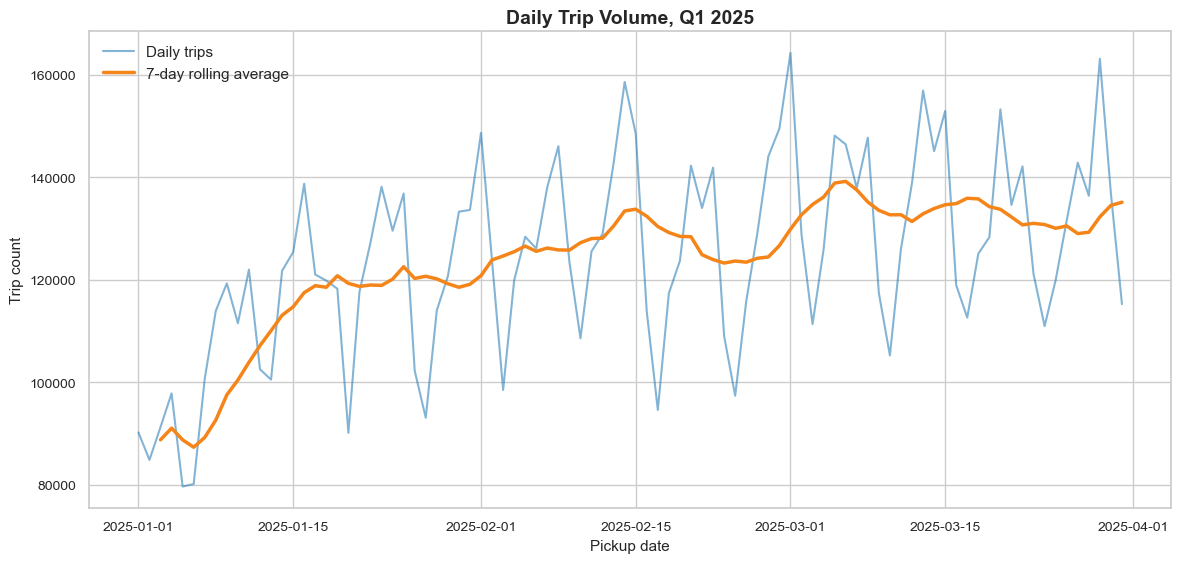

In [8]:
fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(daily_trips.index, daily_trips.values, color=PRIMARY, linewidth=1.5, alpha=0.55, label="Daily trips")
ax.plot(rolling_7d.index, rolling_7d.values, color=ACCENT, linewidth=2.5, label="7-day rolling average")
ax.set_title("Daily Trip Volume, Q1 2025")
ax.set_xlabel("Pickup date")
ax.set_ylabel("Trip count")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

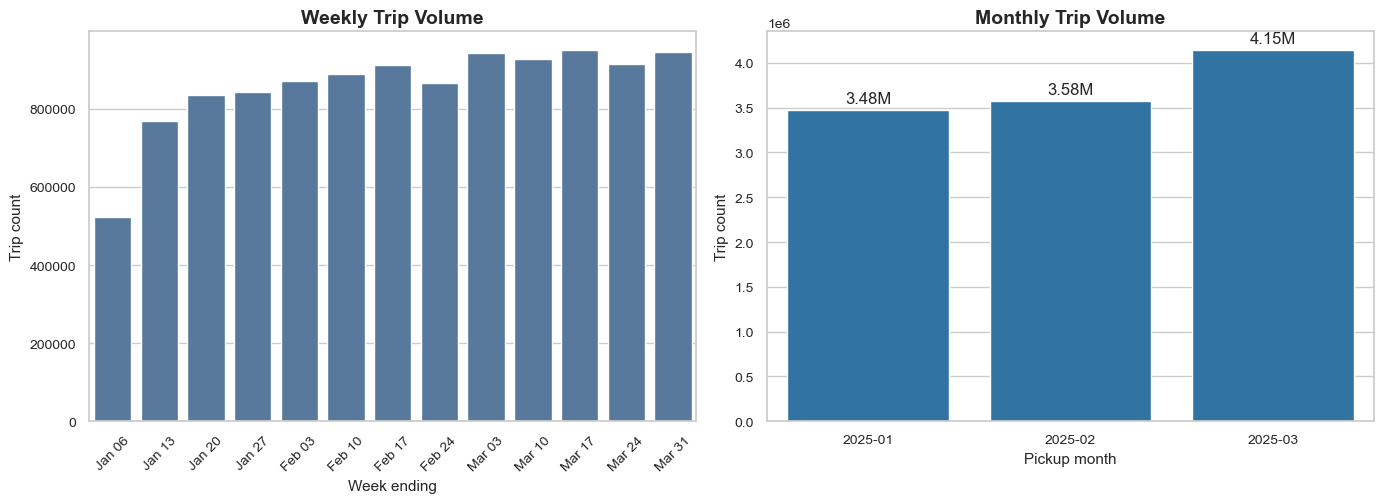

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

sns.barplot(x=weekly_trips.index.strftime("%b %d"), y=weekly_trips.values, color=SECONDARY, ax=axes[0])
axes[0].set_title("Weekly Trip Volume")
axes[0].set_xlabel("Week ending")
axes[0].set_ylabel("Trip count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=monthly_trips.index.astype(str), y=monthly_trips.values, color=PRIMARY, ax=axes[1])
axes[1].set_title("Monthly Trip Volume")
axes[1].set_xlabel("Pickup month")
axes[1].set_ylabel("Trip count")
for container in axes[1].containers:
    axes[1].bar_label(container, labels=[f"{v/1_000_000:.2f}M" for v in monthly_trips.values], padding=3)

plt.tight_layout()
plt.show()

**Observation:** March has the highest monthly volume, while January is the lowest full month. Daily demand averages about 124 thousand trips, with a clear need to smooth daily volatility using a rolling average.

**Interpretation:** Demand appears to strengthen through the quarter, but single-day peaks and troughs should not be over-interpreted without calendar and weather context.

**Business implication:** Staffing, fleet availability, and service planning should be based on rolling and monthly patterns rather than isolated daily spikes.

# 3. Trip Distance Distribution

Trip distance shows whether the business is dominated by short urban trips or longer airport/suburban trips.

In [10]:
distance_stats = summary_stats(eda, "trip_distance")
distance_stats

,metric,value
0,count,"11,198,026.00"
1,missing,0.00
2,mean,6.18
3,median,1.72
4,std,581.82
5,min,0.00
6,p05,0.39
7,p25,1.00
8,p75,3.24
9,p95,11.63


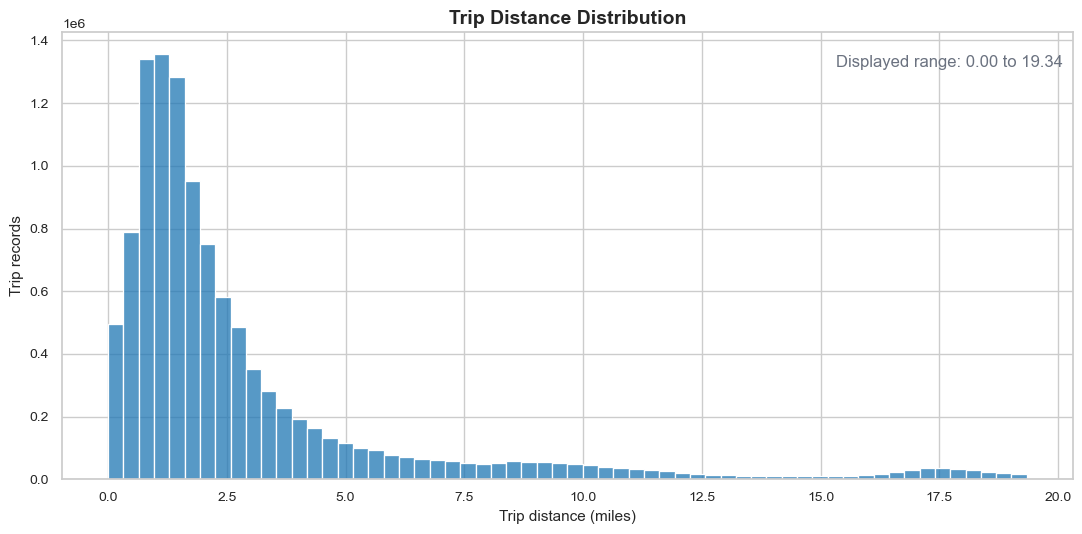

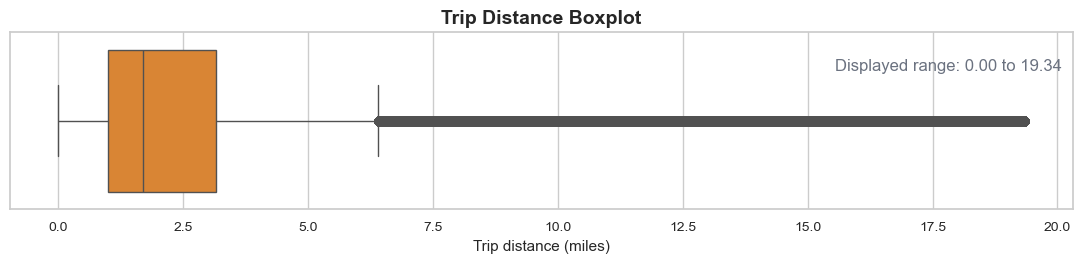

In [11]:
plot_histogram(eda, "trip_distance", "Trip Distance Distribution", "Trip distance (miles)", upper_q=0.99, bins=60)
plot_boxplot(eda, "trip_distance", "Trip Distance Boxplot", "Trip distance (miles)", upper_q=0.99)

**Observation:** The distance distribution is strongly right-skewed. The median trip is about 1.7 miles, while the 99th percentile is about 19 miles and the maximum is implausibly high.

**Interpretation:** Most trips are short urban movements, with a smaller long-trip tail. The extreme maximum is suspicious and should not drive executive conclusions about normal trip length.

**Business implication:** Typical-service planning should focus on short-trip turnover, while outlier handling should remain visible in any revenue or distance reporting.

# 4. Trip Duration Distribution

Trip duration helps assess operating speed, congestion exposure, and how long vehicles are occupied per trip.

In [12]:
duration_stats = summary_stats(eda, "trip_duration_min")
duration_stats

,metric,value
0,count,"11,168,484.00"
1,missing,"29,542.00"
2,mean,15.54
3,median,12.17
4,std,26.13
5,min,0.02
6,p05,3.48
7,p25,7.58
8,p75,18.97
9,p95,37.23


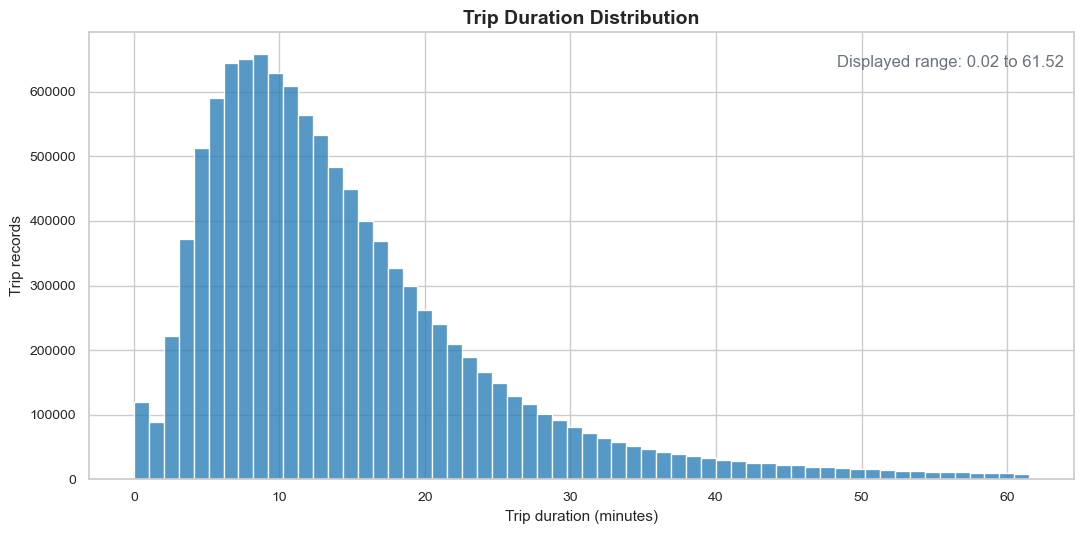

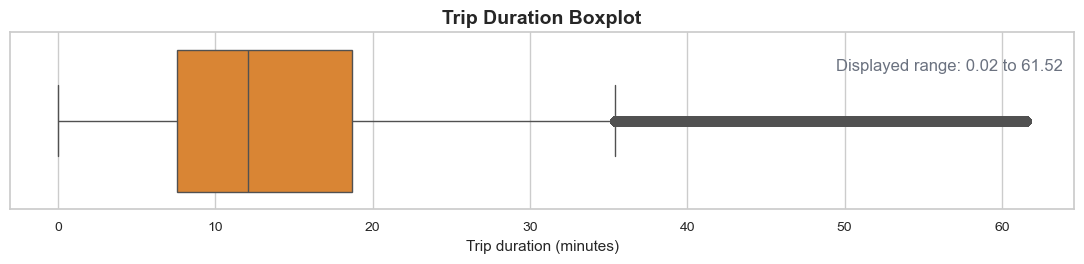

In [13]:
plot_histogram(eda, "trip_duration_min", "Trip Duration Distribution", "Trip duration (minutes)", upper_q=0.99, bins=60)
plot_boxplot(eda, "trip_duration_min", "Trip Duration Boxplot", "Trip duration (minutes)", upper_q=0.99)

**Observation:** Typical trips are short to moderate in duration, with a median near 12 minutes. A long tail extends past one hour, and some records approach the validation ceiling.

**Interpretation:** The distribution is consistent with dense urban service, but long-duration outliers may reflect congestion, airport trips, data-entry issues, or unusual waits.

**Business implication:** Duration percentiles are more useful than averages for operational planning because long trips can distort vehicle-utilization assumptions.

# 5. Fare Amount Distribution

Fare amount reflects metered trip revenue before the full set of surcharges, tolls, and tips are considered.

In [14]:
fare_stats = summary_stats(eda, "fare_amount")
fare_stats

,metric,value
0,count,"11,198,026.00"
1,missing,0.00
2,mean,17.24
3,median,12.80
4,std,261.99
5,min,"-1,807.60"
6,p05,3.00
7,p25,8.60
8,p75,20.50
9,p95,51.30


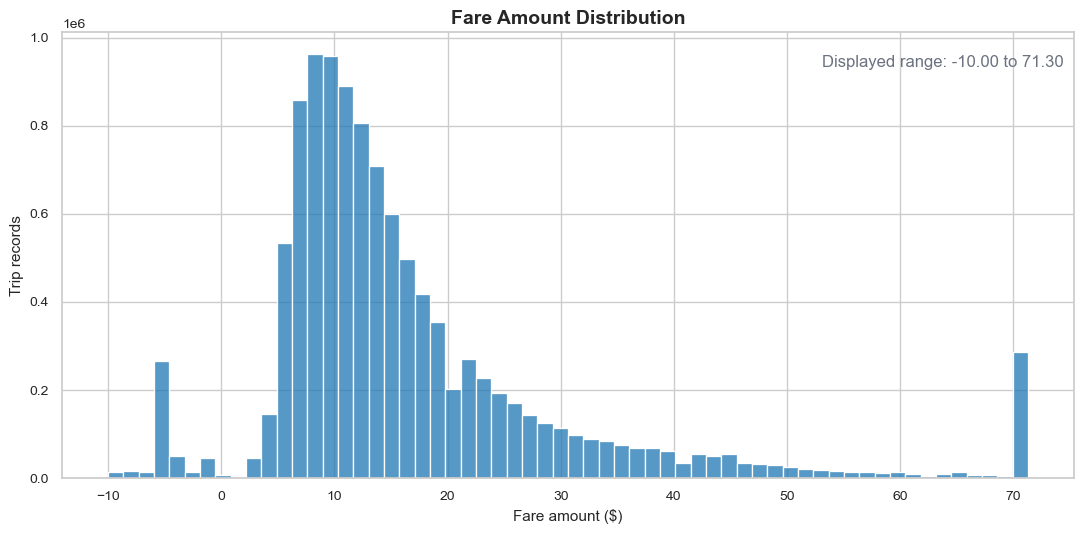

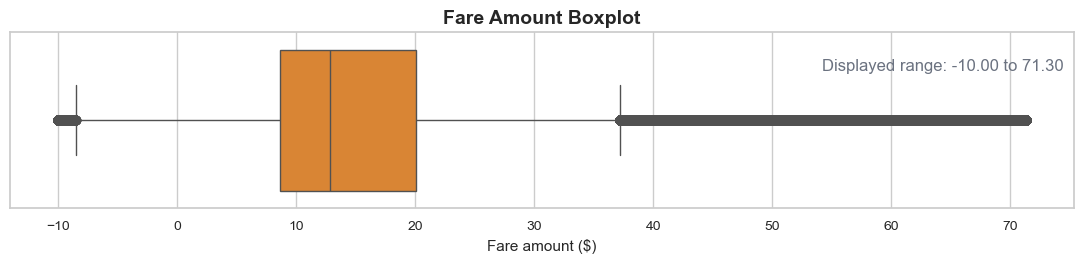

In [15]:
plot_histogram(eda, "fare_amount", "Fare Amount Distribution", "Fare amount ($)", lower_q=0.01, upper_q=0.99, bins=60)
plot_boxplot(eda, "fare_amount", "Fare Amount Boxplot", "Fare amount ($)", lower_q=0.01, upper_q=0.99)

**Observation:** Fare amount is concentrated in lower fare bands, with a median around $13 and a high-cost tail. Negative fare rows and very large fare maxima remain notable caveats.

**Interpretation:** The normal business is dominated by relatively low-to-mid fare trips, while refunds, corrections, or invalid records create suspicious lower and upper extremes.

**Business implication:** Executive fare reporting should separate normal operating fares from exceptional or corrected transactions.

# 6. Total Amount Distribution

Total amount includes fare, tips, tolls, taxes, and surcharges, so it is the better univariate view of customer payment exposure.

In [16]:
total_amount_stats = summary_stats(eda, "total_amount")
total_amount_stats

,metric,value
0,count,"11,198,026.00"
1,missing,0.00
2,mean,25.67
3,median,20.25
4,std,262.31
5,min,"-1,832.85"
6,p05,7.68
7,p25,15.45
8,p75,28.42
9,p95,73.14


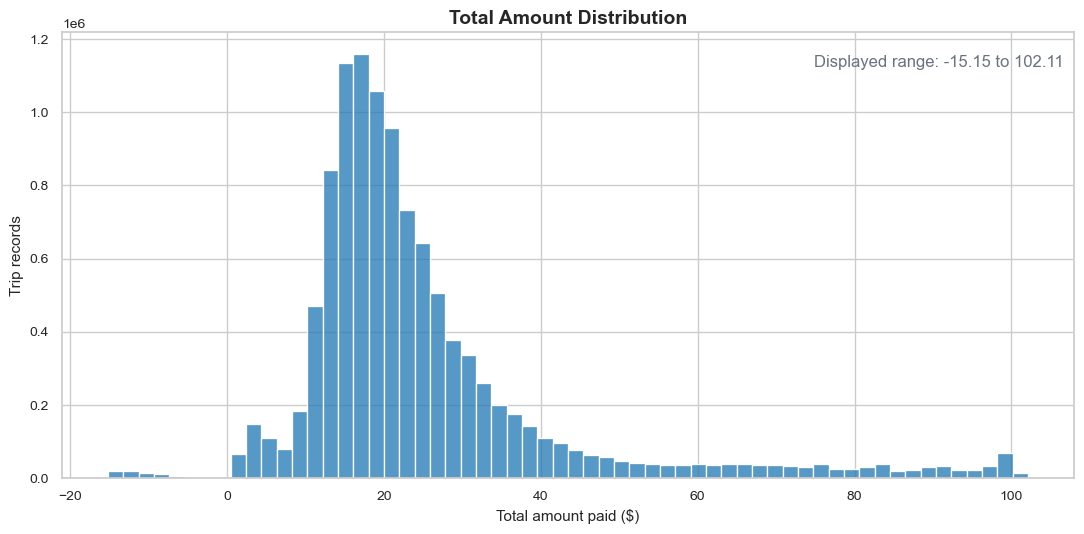

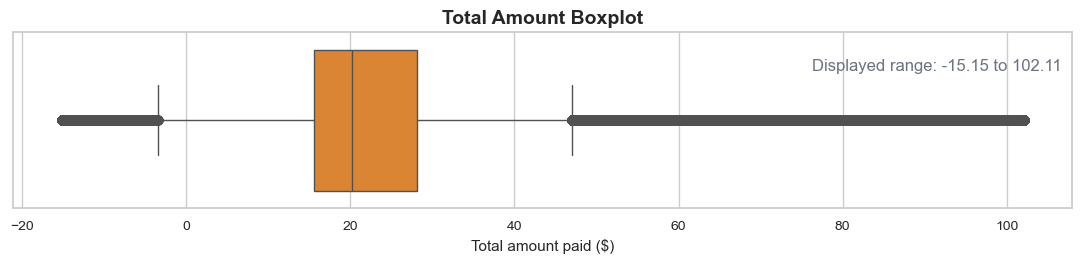

In [17]:
plot_histogram(eda, "total_amount", "Total Amount Distribution", "Total amount paid ($)", lower_q=0.01, upper_q=0.99, bins=60)
plot_boxplot(eda, "total_amount", "Total Amount Boxplot", "Total amount paid ($)", lower_q=0.01, upper_q=0.99)

**Observation:** Total amount is higher than fare amount because it includes tips and surcharges. The median total is about $20, while the upper tail extends beyond $100 at the 99th percentile.

**Interpretation:** Surcharges, tolls, airport-related trips, and tips materially widen the customer-payment distribution.

**Business implication:** Customer-cost reporting should use total amount, not fare amount alone, when discussing price perception and revenue capture.

# 7. Passenger Count Distribution

Passenger count shows the most common ride sizes and flags capacity or missingness issues that matter for interpretation.

In [18]:
passenger_counts = eda["passenger_count"].fillna("Missing").astype(str).value_counts()
ordered_passenger_index = [str(float(i)) for i in range(0, 10) if str(float(i)) in passenger_counts.index]
if "Missing" in passenger_counts.index:
    ordered_passenger_index.append("Missing")
passenger_counts = passenger_counts.loc[ordered_passenger_index]
passenger_share = (passenger_counts / len(eda) * 100).rename("share_pct")
passenger_table = pd.DataFrame({"trip_count": passenger_counts, "share_pct": passenger_share})
passenger_table

,trip_count,share_pct
passenger_count,,
0.0,69122,0.62
1.0,7118030,63.57
2.0,1221270,10.91
3.0,269952,2.41
4.0,169848,1.52
5.0,53050,0.47
6.0,32958,0.29
7.0,12,0.00
8.0,27,0.00


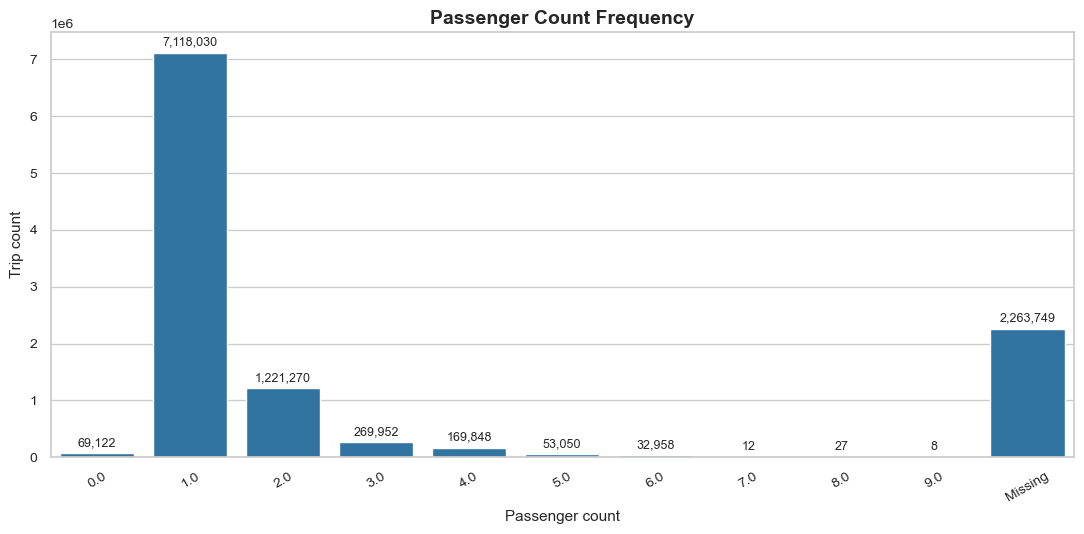

In [19]:
plot_frequency_table(passenger_counts, "Passenger Count Frequency", "Passenger count", "Trip count", color=PRIMARY)

**Observation:** One-passenger trips dominate the dataset, followed by two-passenger trips. Missing passenger counts are also material, and small counts above normal taxi capacity appear.

**Interpretation:** The service is primarily individual or small-party travel. Missing and over-capacity passenger values should be treated as data-quality caveats.

**Business implication:** Capacity planning should assume most yellow taxi trips serve one or two riders, while passenger-count based insights need clear missing-data disclosure.

# 8. Payment Type Frequencies

Payment type frequencies describe how customers pay and whether payment records include operational exceptions.

In [20]:
payment_type_labels = {
    0: "0 - Flex Fare / missing metadata",
    1: "1 - Credit card",
    2: "2 - Cash",
    3: "3 - No charge",
    4: "4 - Dispute",
    5: "5 - Unknown",
    6: "6 - Voided trip",
}

payment_counts = eda["payment_type"].map(payment_type_labels).fillna("Other / missing").value_counts()
payment_counts = payment_counts.reindex([label for label in payment_type_labels.values() if label in payment_counts.index])
payment_table = pd.DataFrame({
    "trip_count": payment_counts,
    "share_pct": payment_counts / len(eda) * 100,
})
payment_table

,trip_count,share_pct
payment_type,,
0 - Flex Fare / missing metadata,2263749,20.22
1 - Credit card,7484734,66.84
2 - Cash,1135757,10.14
3 - No charge,72546,0.65
4 - Dispute,241239,2.15
5 - Unknown,1,0.00


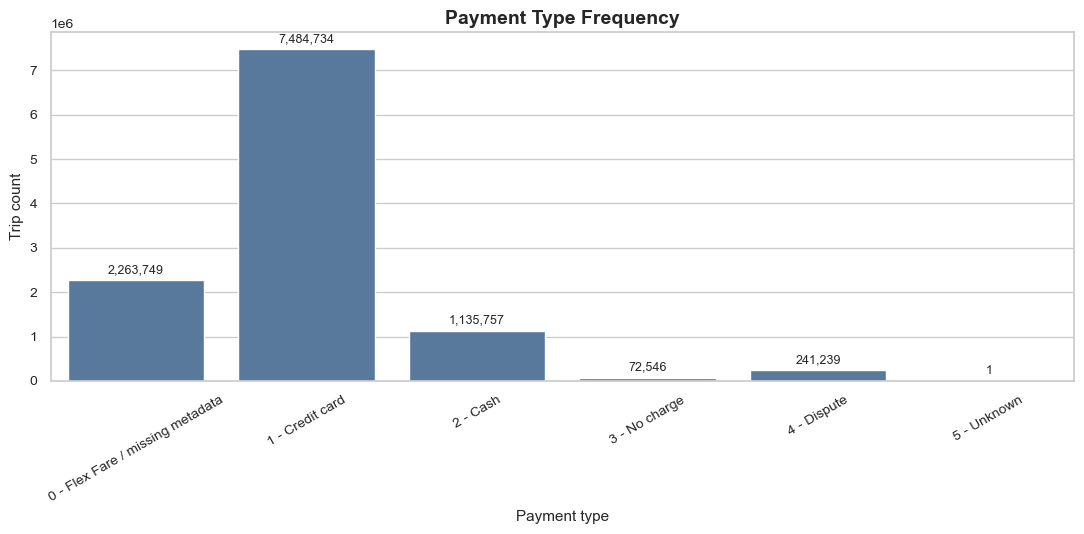

In [21]:
plot_frequency_table(payment_counts, "Payment Type Frequency", "Payment type", "Trip count", color=SECONDARY)

**Observation:** Credit card is the dominant recorded payment type, followed by cash. Type 0 records are also substantial and likely reflect missing or special-provider metadata.

**Interpretation:** Card behavior is central to payment and tipping analysis, but type 0 needs careful treatment before using payment type as a clean customer-behavior variable.

**Business implication:** Executive reporting on payment behavior should distinguish confirmed card/cash trips from records with incomplete payment metadata.

# 9. RateCodeID Frequencies

Rate code identifies the pricing rule applied to a trip, such as standard metered fare, airport fare, or negotiated fare.

In [26]:
ratecode_labels = {
    1.0: "1 - Standard rate",
    2.0: "2 - JFK",
    3.0: "3 - Newark",
    4.0: "4 - Nassau/Westchester",
    5.0: "5 - Negotiated fare",
    6.0: "6 - Group ride",
    99.0: "99 - Unknown/other",
}

rate_series = eda["RatecodeID"].map(ratecode_labels).fillna("Missing")
rate_counts = rate_series.value_counts()
rate_order = [label for label in ratecode_labels.values() if label in rate_counts.index]
if "Missing" in rate_counts.index:
    rate_order.append("Missing")
rate_counts = rate_counts.reindex(rate_order)
rate_table = pd.DataFrame({
    "trip_count": rate_counts,
    "share_pct": rate_counts / len(eda) * 100,
})
rate_table

,trip_count,share_pct
RatecodeID,,
1 - Standard rate,8391053,74.93
2 - JFK,288602,2.58
3 - Newark,27178,0.24
4 - Nassau/Westchester,21318,0.19
5 - Negotiated fare,81032,0.72
6 - Group ride,11,0.00
99 - Unknown/other,125083,1.12
Missing,2263749,20.22


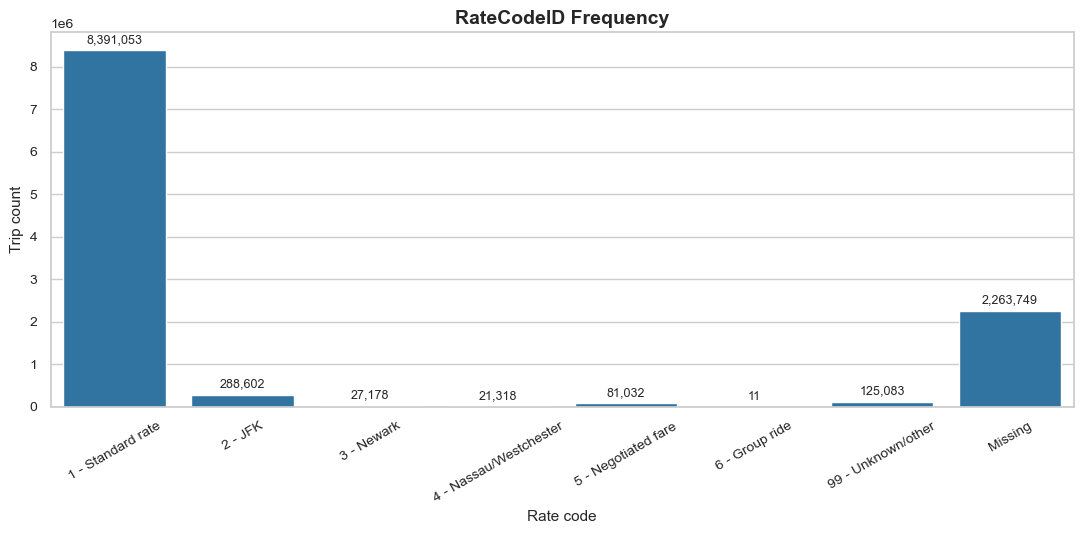

In [27]:
plot_frequency_table(rate_counts, "RateCodeID Frequency", "Rate code", "Trip count", color=PRIMARY)

**Observation:** Standard-rate trips dominate the rate-code distribution. Missing rate codes are material, and rate code 99 appears enough to require disclosure.

**Interpretation:** Most activity is ordinary metered service, while airport, negotiated, and special-code trips form smaller but strategically important segments.

**Business implication:** Future revenue and geography analysis should segment standard-rate trips separately from airport and nonstandard fare structures.

# Top 5 Univariate Insights

1. The analytical dataset is large enough for reliable executive BI, with about 11.2 million trips and roughly $287.4 million in recorded total amount.
2. Trip volume increases across the quarter, with March producing the highest monthly trip count.
3. Typical trips are short: the median distance is about 1.7 miles and the median duration is about 12 minutes, despite long right tails.
4. Fare and total amount distributions are right-skewed and contain suspicious negative and extreme positive values that should remain visible as reporting caveats.
5. Credit card is the dominant confirmed payment type, while passenger count and rate code both contain material missingness that should be disclosed in executive reporting.